# Computer Vision Gesture Pipeline
## MediaPipe + OpenCV → Background Removal → Chamfer Distance

---

**What is this notebook?**  
This notebook walks through a complete computer vision pipeline for hand gesture analysis.  
We take simple phone photos of hand gestures, detect the hand skeleton using AI, remove the background, and finally measure how similar or different the gesture shapes are using Chamfer Distance.

**The 4 steps we follow:**
1. Load gesture images (photos you took on your phone)
2. Detect 21 hand landmarks using MediaPipe (Google's pre-trained AI model)
3. Remove the background using OpenCV — isolate only the hand
4. Compute Chamfer Distance between gesture pairs — quantify shape similarity

**Why does this matter for the research project?**  
In the actual DepthVR system, the Meta Quest headset captures hand images. This pipeline is the foundation for processing those images — detecting the hand shape and comparing gestures. The Chamfer Distance metric will eventually be used to validate that recorded gestures are distinct and recognisable.

---

## Cell 1 — Import Libraries

| Library | Purpose |
|---|---|
| `cv2` (OpenCV) | Image loading, drawing, masking, edge detection |
| `numpy` | All pixel-level array math |
| `mediapipe` | Google's AI model for hand landmark detection |
| `os` | File paths and folder management |
| `itertools.combinations` | Auto-generates all gesture pairs (A,B), (A,C), (B,C) |
| `scipy.spatial.distance.cdist` | Computes distances between two sets of points efficiently |
| `matplotlib` | Displaying images inside the notebook |

In [1]:
import cv2
import numpy as np
import mediapipe as mp
import os
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.spatial.distance import cdist

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## Cell 2 — Configuration

All file paths and settings are defined here in one place.  
If you ever retake photos or move folders, only update this cell.

**About the model file (`hand_landmarker.task`):**  
This is a **pre-trained AI model** made by Google. It was downloaded once using `curl` from Google's servers.  
- Size: 7.6 MB  
- Contents: Millions of numerical weights encoding everything the AI learned about what a hand looks like  
- We did NOT write this — we just load and use it  
- Think of it like downloading a calculator app — you didn't build the calculator, you just use it

In [2]:
BASE_DIR   = '/Users/dewansh/Documents/Summer/HandsOn'
MODEL_PATH = os.path.join(BASE_DIR, 'hand_landmarker.task')   # Pre-trained AI model
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# The 3 gesture images — label → file path
IMAGES = {
    'Thumbs Up': os.path.join(BASE_DIR, 'thumbsup.jpeg'),
    'Victory':   os.path.join(BASE_DIR, 'victory.jpeg'),
    'Open Palm': os.path.join(BASE_DIR, 'openpalm.jpeg'),
}

# Verify model and images exist
print(f'Model file exists: {os.path.exists(MODEL_PATH)} ({MODEL_PATH})')
for name, path in IMAGES.items():
    exists = os.path.exists(path)
    print(f'  {name}: {"✅" if exists else "❌ NOT FOUND"} — {path}')

Model file exists: True (/Users/dewansh/Documents/Summer/HandsOn/hand_landmarker.task)
  Thumbs Up: ✅ — /Users/dewansh/Documents/Summer/HandsOn/thumbsup.jpeg
  Victory: ✅ — /Users/dewansh/Documents/Summer/HandsOn/victory.jpeg
  Open Palm: ✅ — /Users/dewansh/Documents/Summer/HandsOn/openpalm.jpeg


## Cell 3 — Quick Look at the Raw Images

Before processing anything, let's just display the 3 photos as-is.  

> **Note:** OpenCV loads images in **BGR** (Blue-Green-Red) order, but matplotlib expects **RGB** (Red-Green-Blue).  
> `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` swaps the channel order — same image, just correct colour display.

Premature end of JPEG file


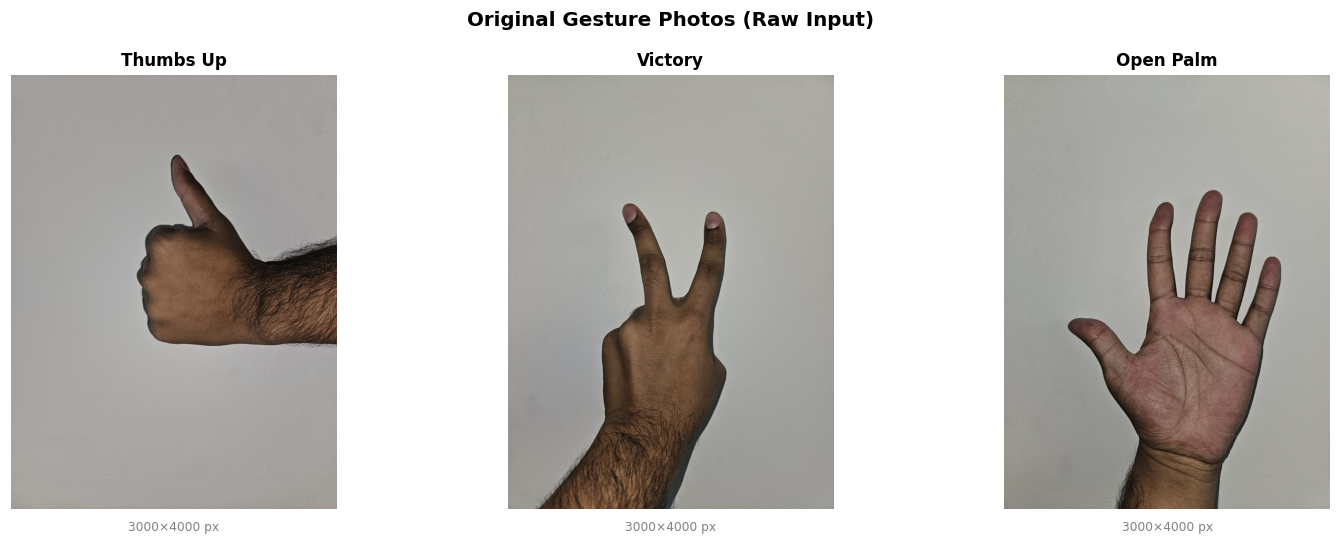

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Original Gesture Photos (Raw Input)', fontsize=13, fontweight='bold')

for ax, (name, path) in zip(axes, IMAGES.items()):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # BGR → RGB for matplotlib
    ax.imshow(img_rgb)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.axis('off')
    ax.text(0.5, -0.05, f'{img.shape[1]}×{img.shape[0]} px',
            ha='center', transform=ax.transAxes, fontsize=8, color='gray')

plt.tight_layout()
plt.show()

---
## STEP 1 — MediaPipe Hand Landmark Detection

### What is MediaPipe?
MediaPipe is an open-source framework by Google that provides ready-to-use AI models for vision tasks.  
We use its `HandLandmarker` model which detects **21 specific points** (landmarks) on a hand.

### The 21 Landmarks
```
          8   12  16  20       ← Fingertips
          |    |   |   |
          7   11  15  19
          |    |   |   |
          6   10  14  18
          |    |   |   |
    4     5    9  13  17
    |      \   |   |  /
    3       -------+--
    |              |
    2              0  ← Wrist
    |
    1  (thumb base)
```

### Normalized vs Pixel Coordinates
MediaPipe returns coordinates as **normalized values between 0.0 and 1.0** — not pixels.  
- `x = 0.0` means far left of the image  
- `x = 1.0` means far right of the image  
- `x = 0.5` means exactly the centre

We convert to pixels by multiplying: `pixel_x = normalized_x × image_width`

### Why draw connections manually?
The older MediaPipe API had a built-in `draw_landmarks()` function.  
In the newer version we use (0.10.35), that function was removed — the API now just gives you raw numbers.  
So we define the bone connections ourselves (once) and draw them with OpenCV.

In [4]:
# Set up MediaPipe shorthand aliases (just to avoid typing long names)
BaseOptions        = mp.tasks.BaseOptions
HandLandmarker     = mp.tasks.vision.HandLandmarker
HandLandmarkerOpts = mp.tasks.vision.HandLandmarkerOptions
RunningMode        = mp.tasks.vision.RunningMode

# Fixed bone connections — these never change (hand anatomy is constant)
# Each tuple (a, b) = draw a line from landmark a to landmark b
CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),          # Thumb:  wrist→metacarpal→proximal→distal→tip
    (0,5),(5,6),(6,7),(7,8),          # Index:  wrist→knuckle→mid→distal→tip
    (0,9),(9,10),(10,11),(11,12),     # Middle
    (0,13),(13,14),(14,15),(15,16),   # Ring
    (0,17),(17,18),(18,19),(19,20),   # Pinky
    (5,9),(9,13),(13,17),             # Palm cross-connections
]

def detect_landmarks(image_bgr):
    """
    Input : BGR image (as loaded by OpenCV)
    Output: (points, annotated_image)
              points         → NumPy array of shape (21, 2) — pixel coords of each landmark
              annotated_image → original image with skeleton drawn on top
    
    Returns (None, image) if no hand is detected.
    """
    h, w = image_bgr.shape[:2]
    
    # Step 1: Convert BGR → RGB (MediaPipe needs RGB)
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    
    # Step 2: Wrap the NumPy array into MediaPipe's Image object
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    
    # Step 3: Configure and run the AI detector
    opts = HandLandmarkerOpts(
        base_options=BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=RunningMode.IMAGE,   # IMAGE mode = single static photo (not video)
        num_hands=1,                      # We only expect 1 hand per photo
        min_hand_detection_confidence=0.3 # Accept if at least 30% confident — more lenient
    )
    with HandLandmarker.create_from_options(opts) as detector:
        result = detector.detect(mp_image)
    
    annotated = image_bgr.copy()   # We'll draw on a copy, keeping original intact
    
    # Step 4: Check if a hand was found
    if not result.hand_landmarks:
        print('  ⚠️  No hand detected — will use skin-colour fallback in background removal')
        return None, annotated
    
    # Step 5: Convert normalized (0.0–1.0) → pixel coordinates
    lm_list = result.hand_landmarks[0]   # [0] = first hand found
    points = np.array([[int(lm.x * w), int(lm.y * h)] for lm in lm_list])
    # points is now shape (21, 2) — 21 joints, each with (x_pixel, y_pixel)
    
    # Step 6: Draw skeleton on the annotated copy
    for a, b in CONNECTIONS:
        cv2.line(annotated, tuple(points[a]), tuple(points[b]),
                 (0, 200, 0), 2)    # green lines, thickness=2
    for pt in points:
        cv2.circle(annotated, tuple(pt), 5,
                   (0, 0, 255), -1) # red filled circles at each joint
    
    return points, annotated

print('✅ detect_landmarks() function defined')
print(f'   Uses model: {MODEL_PATH}')
print(f'   Returns: (21 landmark points, annotated image)')

✅ detect_landmarks() function defined
   Uses model: /Users/dewansh/Documents/Summer/HandsOn/hand_landmarker.task
   Returns: (21 landmark points, annotated image)


---
## STEP 2 — Background Removal

### Goal
Remove everything except the hand — replace background with white.

### Method — Convex Hull Masking
A **convex hull** is the smallest convex polygon that wraps around all given points — like stretching a rubber band around all 21 landmarks.

```
21 landmark points
       ↓
Convex Hull (tight polygon around joints)
       ↓
Expand by 18% (so we don't clip fingertips)
       ↓
Fill polygon = white on black mask
       ↓
Dilate mask (grow outward to fill gaps)
       ↓
Paste hand pixels onto white canvas
```

### Fallback — Skin Colour Segmentation
If MediaPipe fails (no landmarks), we switch to **HSV colour space** to detect skin tones.
- HSV (Hue, Saturation, Value) separates colour from brightness — skin tones occupy a consistent Hue range regardless of lighting
- `cv2.inRange()` marks every pixel whose colour falls within the skin range

In [5]:
def remove_background(image_bgr, landmarks):
    """
    Input : BGR image + 21 landmark points (or None if detection failed)
    Output: (bg_removed_image, binary_mask)
              bg_removed_image → hand on white background
              binary_mask      → white where hand is, black everywhere else
    """
    h, w = image_bgr.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)   # start with all-black mask

    if landmarks is not None:
        # --- METHOD 1: Convex Hull (used when MediaPipe succeeded) ---
        
        # Compute the tightest convex polygon around all 21 joints
        hull = cv2.convexHull(landmarks)
        
        # Find center of the hand
        cx = int(np.mean(landmarks[:, 0]))   # mean of all x coords
        cy = int(np.mean(landmarks[:, 1]))   # mean of all y coords
        
        # Expand hull by 18% outward from center
        # Formula: move each point 18% further away from center
        expanded = ((hull.astype(float) - [cx, cy]) * 1.18 + [cx, cy]).astype(np.int32)
        
        # Fill the polygon with white (255) on the mask
        cv2.fillConvexPoly(mask, expanded, 255)
        
        # Morphological dilation: grow the white region slightly to fill edge gaps
        # MORPH_ELLIPSE kernel is smoother than square — better for organic shapes
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
        mask = cv2.dilate(mask, kernel, iterations=2)

    else:
        # --- METHOD 2: HSV Skin Colour Segmentation (fallback) ---
        
        # Convert BGR → HSV (better for colour-based detection)
        hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
        
        # Define the HSV range for skin tones
        lower = np.array([0, 15, 60],    dtype=np.uint8)   # min hue, sat, val
        upper = np.array([25, 255, 255], dtype=np.uint8)   # max hue, sat, val
        
        # Create mask: 255 where colour is in range, 0 elsewhere
        mask = cv2.inRange(hsv, lower, upper)
        
        # MORPH_CLOSE fills small holes within detected regions
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)

    # --- Combine: paste hand onto white canvas ---
    result = np.full_like(image_bgr, 255)     # all-white canvas same size as image
    result[mask > 0] = image_bgr[mask > 0]   # copy original pixels only where mask is white
    
    return result, mask

print('✅ remove_background() function defined')
print('   Method 1 (landmarks available): Convex Hull → expand 18% → dilate → mask')
print('   Method 2 (no landmarks):        HSV skin-colour segmentation → morphological close')

✅ remove_background() function defined
   Method 1 (landmarks available): Convex Hull → expand 18% → dilate → mask
   Method 2 (no landmarks):        HSV skin-colour segmentation → morphological close


---
## STEP 3 — Chamfer Distance

### What is Chamfer Distance?
It measures **how similar two shapes are** based on their outlines.

**The idea:**  
Take the edge pixels of shape A and shape B.  
For every point on A's edge — find the closest point on B's edge.  
Average all those minimum distances. Do the same from B to A. Average both.

```
CD(A, B) = ( mean(min dist: A→B) + mean(min dist: B→A) ) / 2
```

**Lower = more similar. Zero = identical shapes.**

### Why edges and not the full image?
We only care about the **shape/outline** of the gesture, not the texture or colour of the hand.  
Canny edge detection extracts just the boundary pixels, removing irrelevant interior information.

### Why sample only 600 points?
If the outline has 5000 edge pixels, computing all pairwise distances between two such sets = 5000 × 5000 = 25 million calculations.  
Randomly sampling 600 points per shape keeps it fast (600 × 600 = 360,000) while still giving an accurate estimate.

In [6]:
def get_edge_points(mask, max_pts=600):
    """
    Extract boundary/edge pixels from a binary mask.
    
    Canny edge detection finds pixels where intensity changes sharply
    (i.e., the border between white hand and black background).
    Returns a (N, 2) array of (row, col) coordinates.
    """
    # Canny: 50 and 150 are threshold values — pixels with gradient > 150 are
    # definitely edges, < 50 are definitely not, between = depends on connectivity
    edges = cv2.Canny(mask, 50, 150)
    
    # np.where(edges > 0) returns (rows_array, cols_array) of all edge pixels
    # np.column_stack combines them into shape (N, 2)
    pts = np.column_stack(np.where(edges > 0))
    
    # Random subsample if too many points (for speed)
    if len(pts) > max_pts:
        idx = np.random.choice(len(pts), max_pts, replace=False)
        pts = pts[idx]
    
    return pts


def chamfer_distance(pts_a, pts_b):
    """
    Compute symmetric Chamfer Distance between two point sets.
    
    cdist(A, B) → matrix D of shape (|A|, |B|) where D[i,j] = distance from A[i] to B[j]
    np.min(D, axis=1) → for each point in A, its closest distance to any point in B
    np.min(D, axis=0) → for each point in B, its closest distance to any point in A
    """
    if len(pts_a) == 0 or len(pts_b) == 0:
        return float('inf')   # undefined if either shape is empty
    
    D = cdist(pts_a.astype(float), pts_b.astype(float))   # full distance matrix
    d_a_to_b = np.mean(np.min(D, axis=1))   # A → B: each point in A to nearest in B
    d_b_to_a = np.mean(np.min(D, axis=0))   # B → A: each point in B to nearest in A
    
    return round((d_a_to_b + d_b_to_a) / 2, 2)


print('✅ get_edge_points() and chamfer_distance() defined')
print('   Edge detection: Canny (thresholds 50/150)')
print('   Max points sampled: 600 per shape')
print('   Distance metric: symmetric Chamfer (A→B + B→A) / 2')

✅ get_edge_points() and chamfer_distance() defined
   Edge detection: Canny (thresholds 50/150)
   Max points sampled: 600 per shape
   Distance metric: symmetric Chamfer (A→B + B→A) / 2


---
## STEP 4 — Run the Full Pipeline

Now we loop over all 3 gesture images and apply every step:
1. Load image → resize to 640px (consistent size)
2. Detect landmarks
3. Remove background
4. Save outputs
5. Store everything for comparison

> The `processed` dictionary stores all results — key = gesture name, value = tuple of (original, bg_removed, mask, annotated)

In [7]:
processed = {}   # stores results for all 3 gestures

print('='*55)
print('   Running Pipeline on All 3 Gestures')
print('='*55)

for name, path in IMAGES.items():
    print(f'\n📷  [{name}]')
    
    # Load image
    img = cv2.imread(path)
    if img is None:
        print(f'  ❌  Could not load image: {path}')
        continue
    
    # Resize: longest side = 640px (keeps aspect ratio)
    # Why resize? Consistent size makes Chamfer Distance comparable across images
    h, w = img.shape[:2]
    scale = 640 / max(h, w)
    img = cv2.resize(img, (int(w * scale), int(h * scale)))
    print(f'  📐  Resized to {img.shape[1]}×{img.shape[0]} px')
    
    # Step 1: Landmark detection
    landmarks, annotated = detect_landmarks(img)
    if landmarks is not None:
        print(f'  ✅  Hand detected — {len(landmarks)} landmarks found')
    
    # Step 2: Background removal
    bg_removed, mask = remove_background(img, landmarks)
    print(f'  ✅  Background removed')
    
    # Save output files
    safe_name = name.lower().replace(' ', '_')
    cv2.imwrite(os.path.join(OUTPUT_DIR, f'{safe_name}_landmarks.jpg'), annotated)
    cv2.imwrite(os.path.join(OUTPUT_DIR, f'{safe_name}_bg_removed.jpg'), bg_removed)
    cv2.imwrite(os.path.join(OUTPUT_DIR, f'{safe_name}_mask.jpg'), mask)
    print(f'  💾  Saved: {safe_name}_landmarks.jpg / _bg_removed.jpg / _mask.jpg')
    
    # Store for comparison later
    processed[name] = (img, bg_removed, mask, annotated)

print(f'\n✅  Pipeline complete for {len(processed)} gestures')

   Running Pipeline on All 3 Gestures

📷  [Thumbs Up]
  📐  Resized to 480×640 px


I0000 00:00:1780643139.345664   76206 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 11, prefix = pthread-default
I0000 00:00:1780643139.406809   76206 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1780643139.412492   76210 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780643139.429541   76209 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780643139.440148   76213 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


  ✅  Hand detected — 21 landmarks found
  ✅  Background removed
  💾  Saved: thumbs_up_landmarks.jpg / _bg_removed.jpg / _mask.jpg

📷  [Victory]
  📐  Resized to 480×640 px


Premature end of JPEG file
I0000 00:00:1780643139.804464   76223 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5
W0000 00:00:1780643139.807886   76228 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780643139.810303   76230 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  ✅  Hand detected — 21 landmarks found
  ✅  Background removed
  💾  Saved: victory_landmarks.jpg / _bg_removed.jpg / _mask.jpg

📷  [Open Palm]
  📐  Resized to 480×640 px


I0000 00:00:1780643140.274693   76243 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5
W0000 00:00:1780643140.276773   76245 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780643140.279056   76252 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  ✅  Hand detected — 21 landmarks found
  ✅  Background removed
  💾  Saved: open_palm_landmarks.jpg / _bg_removed.jpg / _mask.jpg

✅  Pipeline complete for 3 gestures


## Visualise Results — Side by Side

Let's display all 4 versions of each gesture (Original → Landmarks → BG Removed → Mask) inline.

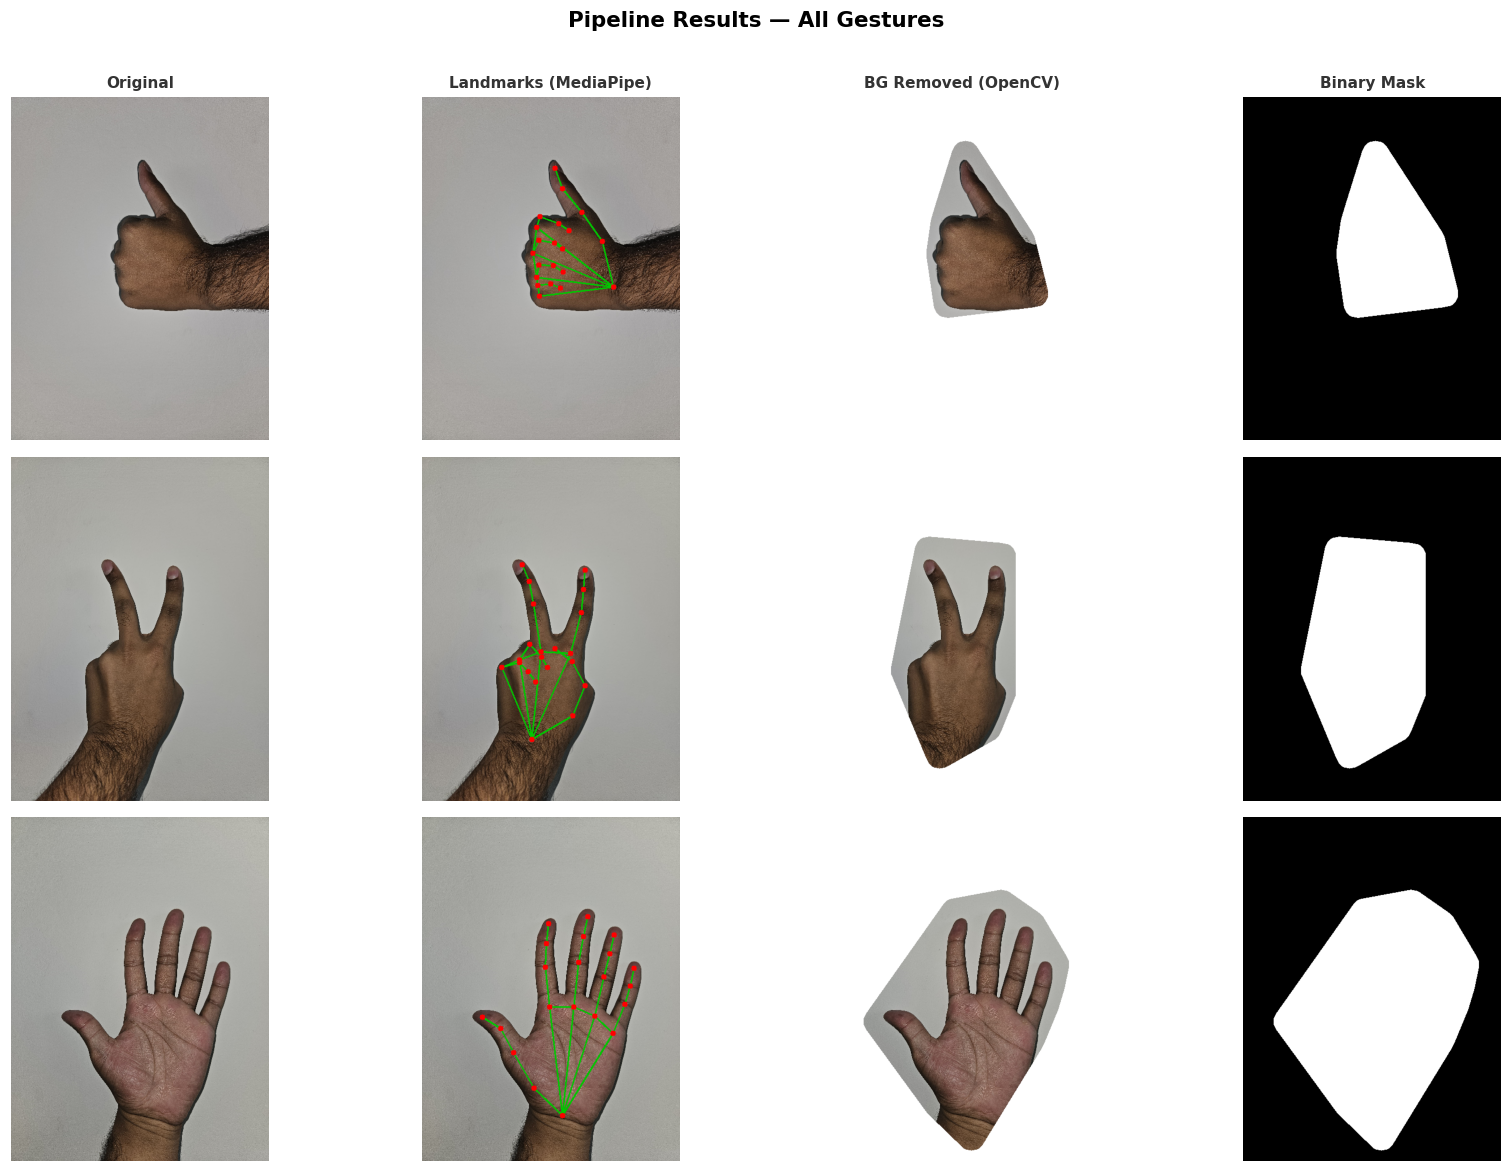

In [8]:
def bgr_to_rgb(img):
    """Convert BGR (OpenCV) → RGB (matplotlib) for correct colour display."""
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

n = len(processed)
fig, axes = plt.subplots(n, 4, figsize=(16, n * 3.5))
fig.suptitle('Pipeline Results — All Gestures', fontsize=14, fontweight='bold', y=1.01)

col_titles = ['Original', 'Landmarks (MediaPipe)', 'BG Removed (OpenCV)', 'Binary Mask']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=10, fontweight='bold', color='#333')

for row_idx, (name, (orig, bg_removed, mask, annotated)) in enumerate(processed.items()):
    images_to_show = [
        bgr_to_rgb(orig),
        bgr_to_rgb(annotated),
        bgr_to_rgb(bg_removed),
        mask   # already grayscale
    ]
    cmaps = [None, None, None, 'gray']
    
    for col_idx, (im, cmap) in enumerate(zip(images_to_show, cmaps)):
        ax = axes[row_idx][col_idx]
        ax.imshow(im, cmap=cmap)
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(name, fontsize=11, fontweight='bold', rotation=90,
                          labelpad=10, va='center')

plt.tight_layout()
plt.show()

---
## STEP 5 — Chamfer Distance Between All Gesture Pairs

`combinations(processed.keys(), 2)` automatically generates all unique pairs:  
→ (Thumbs Up, Victory), (Thumbs Up, Open Palm), (Victory, Open Palm)  
No manual listing needed — works for any number of gestures.

In [9]:
print('='*55)
print('   CHAMFER DISTANCE RESULTS')
print('='*55)
print(f'  {"Pair":<38} {"Distance":>10}')
print('  ' + '-'*50)

distances = {}

for a, b in combinations(processed.keys(), 2):
    # Get binary mask for each gesture
    mask_a = processed[a][2]
    mask_b = processed[b][2]
    
    # Extract edge points from each mask
    pts_a = get_edge_points(mask_a)
    pts_b = get_edge_points(mask_b)
    
    # Compute Chamfer Distance
    d = chamfer_distance(pts_a, pts_b)
    distances[(a, b)] = d
    
    print(f'  {a}  ↔  {b:<20} {d:>8.2f} px')

print('  ' + '-'*50)

best  = min(distances, key=distances.get)
worst = max(distances, key=distances.get)

print(f'\n  🟢 Most SIMILAR  : {best[0]}  ↔  {best[1]}  ({distances[best]} px)')
print(f'  🔴 Most DIFFERENT: {worst[0]}  ↔  {worst[1]}  ({distances[worst]} px)')
print(f'\n  📌 Lower Chamfer Distance = more similar shapes')
print(f'     0 = identical shapes | Higher = more different')

   CHAMFER DISTANCE RESULTS
  Pair                                     Distance
  --------------------------------------------------
  Thumbs Up  ↔  Victory                 53.09 px
  Thumbs Up  ↔  Open Palm               66.77 px
  Victory  ↔  Open Palm               33.71 px
  --------------------------------------------------

  🟢 Most SIMILAR  : Victory  ↔  Open Palm  (33.71 px)
  🔴 Most DIFFERENT: Thumbs Up  ↔  Open Palm  (66.77 px)

  📌 Lower Chamfer Distance = more similar shapes
     0 = identical shapes | Higher = more different


## Visualise Chamfer Distance as a Bar Chart

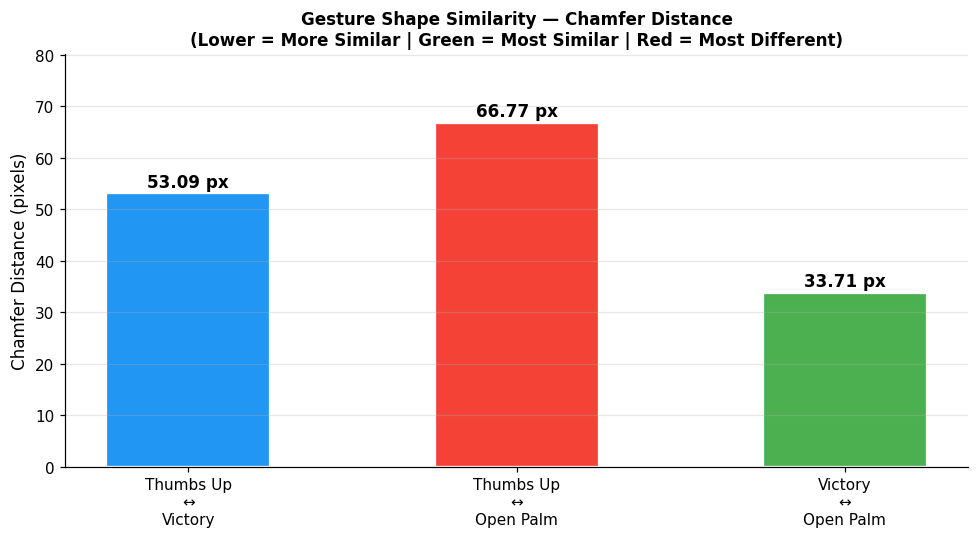

In [10]:
pair_labels = [f'{a}\n↔\n{b}' for (a, b) in distances.keys()]
values = list(distances.values())
colors = ['#4CAF50' if v == min(values) else '#F44336' if v == max(values) else '#2196F3'
          for v in values]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(pair_labels, values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

# Add value labels on top of bars
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.2f} px', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Chamfer Distance (pixels)', fontsize=11)
ax.set_title('Gesture Shape Similarity — Chamfer Distance\n'
             '(Lower = More Similar | Green = Most Similar | Red = Most Different)',
             fontsize=11, fontweight='bold')
ax.set_ylim(0, max(values) * 1.2)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'chamfer_distance_chart.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## STEP 6 — Edge Visualisation

Let's actually see the edge points that Chamfer Distance is computed from.  
This helps you understand *what shape information* is being compared.

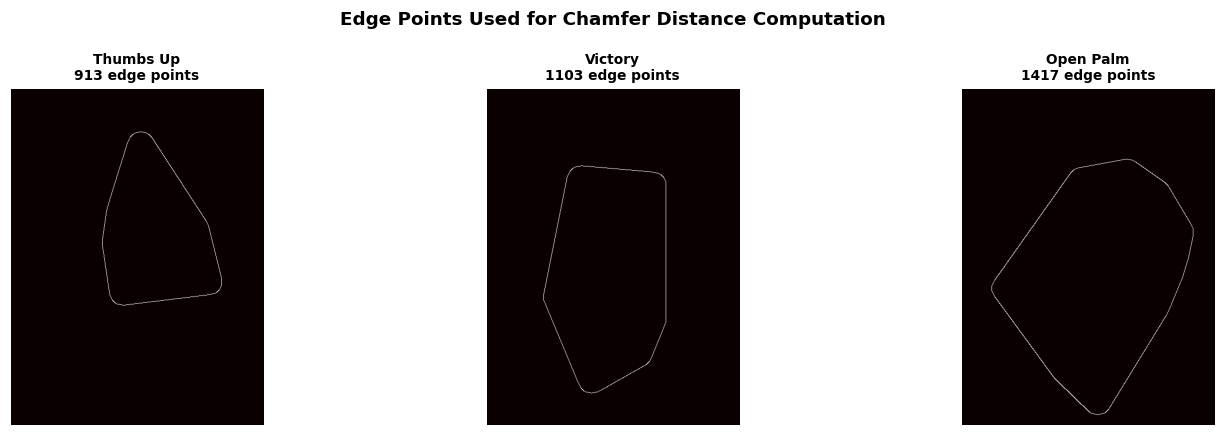

💡 These bright pixels are the "outline" of the hand shape
   Chamfer Distance measures how far apart these outlines are between gestures


In [11]:
fig, axes = plt.subplots(1, len(processed), figsize=(14, 4))
fig.suptitle('Edge Points Used for Chamfer Distance Computation', 
             fontsize=12, fontweight='bold')

for ax, (name, (orig, bg_removed, mask, annotated)) in zip(axes, processed.items()):
    edges = cv2.Canny(mask, 50, 150)   # detect edges from mask
    pts = np.column_stack(np.where(edges > 0))   # get (row, col) of edge pixels
    
    ax.imshow(edges, cmap='hot')   # show edge image
    ax.set_title(f'{name}\n{len(pts)} edge points', fontsize=9, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()
print('💡 These bright pixels are the "outline" of the hand shape')
print('   Chamfer Distance measures how far apart these outlines are between gestures')

---
## Summary

### What this pipeline does:
```
Phone Photos (3 gestures)
       │
       ▼
[Load & Resize to 640px]
       │
       ▼
[MediaPipe AI] → detects 21 hand joints (normalized → pixel coords)
       │
       ▼
[OpenCV] → convex hull → expand → fill mask → dilate → paste on white
       │
       ▼
[Canny Edge Detection] → extracts hand outline pixels
       │
       ▼
[Chamfer Distance] → distance matrix → how similar are 2 shapes?
       │
       ▼
Results + Visualisations saved to output/
```

### Key Observations:
1. **Chamfer Distance varies between photo sessions** even for the same gesture — hand angle, scale, and finger spread all affect the edge shape. This is why the study uses **3 orientations per gesture**.
2. **MediaPipe can fail** with non-white backgrounds or poor lighting — the skin-colour fallback handles this gracefully.
3. **The connections list is written once** — it does not scale with dataset size. Only the processing loop scales.

### Outputs saved:
```
output/
├── <gesture>_landmarks.jpg     — MediaPipe skeleton overlay
├── <gesture>_bg_removed.jpg    — Hand on white background  
├── <gesture>_mask.jpg          — Binary mask
└── chamfer_distance_chart.png  — Bar chart of distances
```